# Sentiment Based Product Recommendation System

MSc Data Science & AI Capstone — Arun K

Regular recommenders suggest products based on what similar users liked. The problem is ratings don't tell the full story — a 4-star product can still have loads of complaints. So after collaborative filtering gives the top 20 candidates, I run sentiment analysis on their reviews and return only the top 5 with the highest positive ratio.

Dataset: `sample30.csv` — around 30,000 Ebuss product reviews.

## Imports

In [7]:
# import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pickle
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_sample_weight

sns.set_style('whitegrid')

## Task 1 - Data Cleaning

Load the dataset, check what we have, drop unusable columns and handle nulls.

In [8]:
df = pd.read_csv('sample30.csv', encoding='latin-1')
print(df.shape)
print(df.dtypes)
print()
print(df.isnull().sum().sort_values(ascending=False))
print()
print(df['user_sentiment'].value_counts(normalize=True).round(3))
df.head()

(30000, 15)
id                      object
brand                   object
categories              object
manufacturer            object
name                    object
reviews_date            object
reviews_didPurchase     object
reviews_doRecommend     object
reviews_rating           int64
reviews_text            object
reviews_title           object
reviews_userCity        object
reviews_userProvince    object
reviews_username        object
user_sentiment          object
dtype: object

reviews_userProvince    29830
reviews_userCity        28071
reviews_didPurchase     14068
reviews_doRecommend      2570
reviews_title             190
manufacturer              141
reviews_username           63
reviews_date               46
user_sentiment              1
id                          0
brand                       0
categories                  0
name                        0
reviews_rating              0
reviews_text                0
dtype: int64

user_sentiment
Positive    0.888
Negative   

,id,brand,categories,manufacturer,name,reviews_date,reviews_didPurchase,reviews_doRecommend,reviews_rating,reviews_text,reviews_title,reviews_userCity,reviews_userProvince,reviews_username,user_sentiment
0,AV13O1A8GV-KLJ3akUyj,Universal Music,"Movies, Music & Books,Music,R&b,Movies & TV,Mo...",Universal Music Group / Cash Money,Pink Friday: Roman Reloaded Re-Up (w/dvd),2012-11-30T06:21:45.000Z,NaN,NaN,5,i love this album. it's very good. more to the...,Just Awesome,Los Angeles,NaN,joshua,Positive
1,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Co...",Lundberg,Lundberg Organic Cinnamon Toast Rice Cakes,2017-07-09T00:00:00.000Z,True,NaN,5,Good flavor. This review was collected as part...,Good,NaN,NaN,dorothy w,Positive
2,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Co...",Lundberg,Lundberg Organic Cinnamon Toast Rice Cakes,2017-07-09T00:00:00.000Z,True,NaN,5,Good flavor.,Good,NaN,NaN,dorothy w,Positive
3,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Sperm...",K-Y,K-Y Love Sensuality Pleasure Gel,2016-01-06T00:00:00.000Z,False,False,1,I read through the reviews on here before look...,Disappointed,NaN,NaN,rebecca,Negative
4,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Sperm...",K-Y,K-Y Love Sensuality Pleasure Gel,2016-12-21T00:00:00.000Z,False,False,1,My husband bought this gel for us. The gel cau...,Irritation,NaN,NaN,walker557,Negative


In [9]:
# drop columns that are mostly empty or not useful for the model
drop_cols = ['reviews_userCity', 'reviews_userProvince', 'reviews_didPurchase',
             'reviews_date', 'manufacturer', 'id', 'categories']
df.drop(columns=drop_cols, inplace=True)
df.shape

(30000, 8)

In [10]:
# fill remaining nulls
df['reviews_title'] = df['reviews_title'].fillna('')
df['reviews_doRecommend'] = df['reviews_doRecommend'].fillna(df['reviews_doRecommend'].mode()[0])
df['reviews_username'] = df['reviews_username'].fillna('unknown_user')
df.dropna(subset=['user_sentiment'], inplace=True)
df.isnull().sum()

brand                  0
name                   0
reviews_doRecommend    0
reviews_rating         0
reviews_text           0
reviews_title          0
reviews_username       0
user_sentiment         0
dtype: int64

In [11]:
# encode sentiment as binary and combine title and review text
df['sentiment_label'] = df['user_sentiment'].map({'Positive': 1, 'Negative': 0})
df['reviews_combined'] = (df['reviews_title'].str.strip() + ' ' + df['reviews_text'].str.strip()).str.strip()
df[['user_sentiment', 'sentiment_label', 'reviews_combined']].head(3)

,user_sentiment,sentiment_label,reviews_combined
0,Positive,1,Just Awesome i love this album. it's very good...
1,Positive,1,Good Good flavor. This review was collected as...
2,Positive,1,Good Good flavor.


## Task 2 - Text Preprocessing

Lowercase, remove noise, strip stopwords and lemmatise the review text.

In [12]:
# text cleaning function using stopword removal and lemmatisation
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [lemmatizer.lemmatize(t) for t in text.split()
              if t not in stop_words and len(t) > 1]
    return ' '.join(tokens)

In [13]:
# apply preprocessing and remove empty results
df['clean_text'] = df['reviews_combined'].apply(preprocess_text)
df = df[df['clean_text'].str.strip() != '']
df[['reviews_combined', 'clean_text']].head(3)

,reviews_combined,clean_text
0,Just Awesome i love this album. it's very good...,awesome love album good hip hop side current p...
1,Good Good flavor. This review was collected as...,good good flavor review collected part promotion
2,Good Good flavor.,good good flavor


## Task 3 - Feature Extraction

Stratified train/test split, then TF-IDF vectorisation with unigrams and bigrams.

In [14]:
# stratified train/test split
X = df['clean_text']
y = df['sentiment_label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape, X_test.shape)

(23999,) (6000,)


In [15]:
# fit TF-IDF vectoriser on training data
tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1, 2), min_df=2, sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print(X_train_tfidf.shape, X_test_tfidf.shape)

(23999, 50000) (6000, 50000)


## Task 4 - Sentiment Classification

Train four classifiers and compare using weighted F1. Dataset is 89% positive so using `class_weight='balanced'` throughout.

In [16]:
# evaluation helper — prints metrics and returns a results dict
def evaluate_model(model, name):
    y_pred = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)
    f1_w = f1_score(y_test, y_pred, average='weighted')
    f1_neg = f1_score(y_test, y_pred, pos_label=0)
    print(f'\n{name}')
    print(f'Accuracy      : {acc:.4f}')
    print(f'F1 (weighted) : {f1_w:.4f}')
    print(f'F1 (negative) : {f1_neg:.4f}')
    print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))
    return {'model': name, 'accuracy': acc, 'f1_weighted': f1_w, 'f1_negative': f1_neg}

results = []

In [17]:
# logistic regression
lr = LogisticRegression(C=5, max_iter=1000, class_weight='balanced', solver='saga', random_state=42)
lr.fit(X_train_tfidf, y_train)
results.append(evaluate_model(lr, 'Logistic Regression'))


Logistic Regression
Accuracy      : 0.9120
F1 (weighted) : 0.9152
F1 (negative) : 0.6408
              precision    recall  f1-score   support

    Negative       0.59      0.70      0.64       673
    Positive       0.96      0.94      0.95      5327

    accuracy                           0.91      6000
   macro avg       0.78      0.82      0.80      6000
weighted avg       0.92      0.91      0.92      6000



In [18]:
# multinomial naive bayes with manual sample weights
sample_weights = compute_sample_weight('balanced', y_train)
nb = MultinomialNB(alpha=0.1)
nb.fit(X_train_tfidf, y_train, sample_weight=sample_weights)
results.append(evaluate_model(nb, 'Multinomial Naive Bayes'))


Multinomial Naive Bayes
Accuracy      : 0.8717
F1 (weighted) : 0.8772
F1 (negative) : 0.4853
              precision    recall  f1-score   support

    Negative       0.44      0.54      0.49       673
    Positive       0.94      0.91      0.93      5327

    accuracy                           0.87      6000
   macro avg       0.69      0.73      0.71      6000
weighted avg       0.88      0.87      0.88      6000



In [19]:
# linear svm
svm = LinearSVC(C=1.0, class_weight='balanced', max_iter=2000, random_state=42)
svm.fit(X_train_tfidf, y_train)
results.append(evaluate_model(svm, 'Linear SVM'))


Linear SVM
Accuracy      : 0.9158
F1 (weighted) : 0.9165
F1 (negative) : 0.6317
              precision    recall  f1-score   support

    Negative       0.62      0.64      0.63       673
    Positive       0.95      0.95      0.95      5327

    accuracy                           0.92      6000
   macro avg       0.79      0.80      0.79      6000
weighted avg       0.92      0.92      0.92      6000



In [20]:
# random forest
rf = RandomForestClassifier(n_estimators=200, max_depth=20,
                            class_weight='balanced', n_jobs=-1, random_state=42)
rf.fit(X_train_tfidf, y_train)
results.append(evaluate_model(rf, 'Random Forest'))


Random Forest
Accuracy      : 0.8513
F1 (weighted) : 0.8688
F1 (negative) : 0.5285
              precision    recall  f1-score   support

    Negative       0.41      0.74      0.53       673
    Positive       0.96      0.87      0.91      5327

    accuracy                           0.85      6000
   macro avg       0.69      0.80      0.72      6000
weighted avg       0.90      0.85      0.87      6000



                  model  accuracy  f1_weighted  f1_negative
             Linear SVM  0.915833     0.916502     0.631656
    Logistic Regression  0.912000     0.915193     0.640816
Multinomial Naive Bayes  0.871667     0.877184     0.485294
          Random Forest  0.851333     0.868769     0.528541


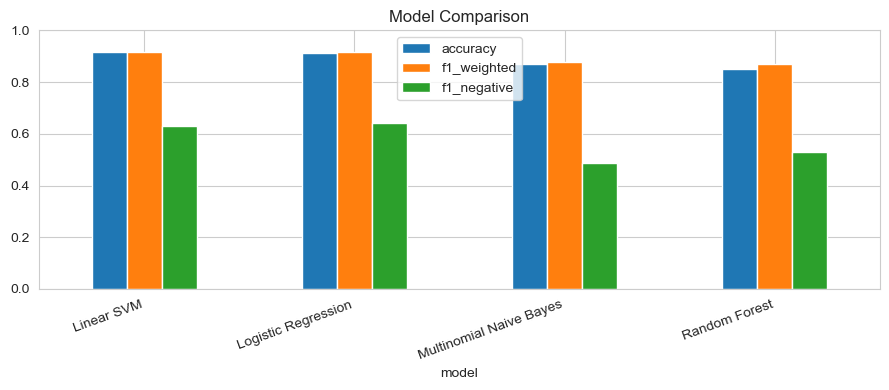

In [21]:
# compare all models and plot results
results_df = pd.DataFrame(results).sort_values('f1_weighted', ascending=False)
print(results_df.to_string(index=False))

results_df.plot(x='model', y=['accuracy', 'f1_weighted', 'f1_negative'],
                kind='bar', figsize=(9, 4), ylim=(0, 1))
plt.title('Model Comparison')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

Best model: Linear SVM


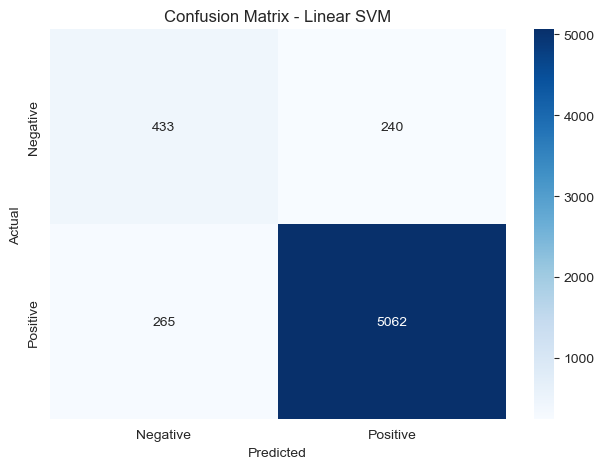

In [22]:
# pick the best model and plot its confusion matrix
best_model_name = results_df.iloc[0]['model']
best_model = {'Logistic Regression': lr, 'Multinomial Naive Bayes': nb,
              'Linear SVM': svm, 'Random Forest': rf}[best_model_name]
print('Best model:', best_model_name)

cm = confusion_matrix(y_test, best_model.predict(X_test_tfidf))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [23]:
# save the best model and vectoriser
pickle.dump(best_model, open('sentiment_model.pkl', 'wb'))
pickle.dump(tfidf, open('tfidf_vectorizer.pkl', 'wb'))
print('Saved sentiment_model.pkl and tfidf_vectorizer.pkl')

Saved sentiment_model.pkl and tfidf_vectorizer.pkl


## Task 5 - Collaborative Filtering

Build user-based and item-based CF using cosine similarity on the ratings matrix. Pick the better one by RMSE on a 30% holdout.

In [24]:
# build ratings matrix and set up train/test split and dummy mask
ratings_df = (df[['reviews_username', 'name', 'reviews_rating']]
              .groupby(['reviews_username', 'name'])['reviews_rating']
              .mean().reset_index())

train_cf, test_cf = train_test_split(ratings_df, test_size=0.3, random_state=42)

train_pivot = train_cf.pivot_table(index='reviews_username',
                                   columns='name', values='reviews_rating')

dummy_train = train_cf.copy()
dummy_train['reviews_rating'] = dummy_train['reviews_rating'].apply(lambda x: 0 if x >= 1 else 1)
dummy_train = dummy_train.pivot_table(index='reviews_username',
                                      columns='name', values='reviews_rating').fillna(1)

print(train_pivot.shape, dummy_train.shape)

(17891, 253) (17891, 253)


### User-based Collaborative Filtering

In [25]:
# user similarity with adjusted cosine and predict ratings
mean_user = np.nanmean(train_pivot, axis=1)
df_user_centered = (train_pivot.T - mean_user).T

user_correlation = 1 - pairwise_distances(df_user_centered.fillna(0), metric='cosine')
user_correlation = np.clip(user_correlation, 0, None)
user_correlation[np.isnan(user_correlation)] = 0

user_predicted_ratings = np.dot(user_correlation, train_pivot.fillna(0))
user_final_rating = pd.DataFrame(
    np.multiply(user_predicted_ratings, dummy_train),
    index=train_pivot.index, columns=train_pivot.columns)
user_final_rating.shape

(17891, 253)

### Item-based Collaborative Filtering

In [26]:
# item similarity with adjusted cosine and predict ratings
train_pivot_T = train_pivot.T
mean_item = np.nanmean(train_pivot_T, axis=1)
df_item_centered = (train_pivot_T.T - mean_item).T

item_correlation = 1 - pairwise_distances(df_item_centered.fillna(0), metric='cosine')
item_correlation = np.clip(item_correlation, 0, None)
item_correlation[np.isnan(item_correlation)] = 0

item_predicted_ratings = np.dot(train_pivot.fillna(0), item_correlation)
item_final_rating = pd.DataFrame(
    np.multiply(item_predicted_ratings, dummy_train),
    index=train_pivot.index, columns=train_pivot.columns)
item_final_rating.shape

(17891, 253)

### Comparing RMSE

In [27]:
# RMSE function to evaluate CF predictions against the holdout
def rmse_for_cf(final_rating_df, train_pivot, test_cf):
    common = test_cf[test_cf['reviews_username'].isin(train_pivot.index)
                     & test_cf['name'].isin(train_pivot.columns)]
    if common.empty:
        return None

    actual = common.pivot_table(index='reviews_username',
                                columns='name', values='reviews_rating')
    dummy_test = common.copy()
    dummy_test['reviews_rating'] = dummy_test['reviews_rating'].apply(lambda x: 1 if x >= 1 else 0)
    dummy_test = dummy_test.pivot_table(index='reviews_username',
                                        columns='name', values='reviews_rating').fillna(0)

    users = actual.index.intersection(final_rating_df.index)
    cols = actual.columns.intersection(final_rating_df.columns)
    pred = final_rating_df.loc[users, cols]
    actual = actual.loc[users, cols]
    mask = dummy_test.reindex(index=users, columns=cols).fillna(0)
    pred_masked = np.multiply(pred.values, mask.values)

    nonzero = pred_masked[pred_masked > 0]
    if nonzero.size == 0:
        return None
    scaled = MinMaxScaler((1, 5)).fit_transform(nonzero.reshape(-1, 1)).flatten()
    y_actual = actual.values[(pred_masked > 0)[:actual.shape[0], :actual.shape[1]]]
    n = min(len(scaled), len(y_actual))
    return float(np.sqrt(np.nanmean((y_actual[:n] - scaled[:n]) ** 2)))

In [28]:
# compare RMSE and select the better CF model
rmse_ubcf = rmse_for_cf(user_final_rating, train_pivot, test_cf)
rmse_ibcf = rmse_for_cf(item_final_rating, train_pivot, test_cf)
print(f'User-based CF RMSE : {rmse_ubcf}')
print(f'Item-based CF RMSE : {rmse_ibcf}')

if rmse_ubcf and rmse_ibcf and rmse_ubcf <= rmse_ibcf:
    best_cf, best_final_rating = 'user_based', user_final_rating
elif rmse_ubcf and rmse_ibcf:
    best_cf, best_final_rating = 'item_based', item_final_rating
else:
    best_cf, best_final_rating = 'user_based', user_final_rating
print('Selected:', best_cf)

User-based CF RMSE : 3.0411018126107026
Item-based CF RMSE : 2.54224572291479
Selected: item_based


## Task 6 - Top 20 Recommendations

Get the top 20 unrated products for a given user from the selected CF model.

In [29]:
# return top 20 unseen products for a user
def recommend_top20(username):
    if username not in best_final_rating.index:
        print(f"User '{username}' not found.")
        return pd.DataFrame()
    top20 = best_final_rating.loc[username].sort_values(ascending=False)
    top20 = top20[top20 > 0].head(20)
    return pd.DataFrame({'rank': range(1, len(top20) + 1),
                         'name': top20.index,
                         'predicted_score': top20.values.round(4)})

In [30]:
# show top 20 for a sample user
sample_user = best_final_rating.index[0]
print(f"Top 20 for '{sample_user}'")
print(recommend_top20(sample_user).to_string(index=False))

Top 20 for '00dog3'
 rank                                                                            name  predicted_score
    1                                                          Hormel Chili, No Beans           0.0282
    2 Pendaflex174 Divide It Up File Folder, Multi Section, Letter, Assorted, 12/pack           0.0278
    3                               Caress Moisturizing Body Bar Natural Silk, 4.75oz           0.0219
    4                            My Big Fat Greek Wedding 2 (blu-Ray + Dvd + Digital)           0.0140
    5             Planes: Fire Rescue (2 Discs) (includes Digital Copy) (blu-Ray/dvd)           0.0094
    6                                                 Burt's Bees Lip Shimmer, Raisin           0.0083
    7                                            Clorox Disinfecting Bathroom Cleaner           0.0045
    8                       Clorox Disinfecting Wipes Value Pack Scented 150 Ct Total           0.0033


## Task 7 - Sentiment-Based Filtering

For each of the 20 CF candidates, run the sentiment model on their reviews and keep the top 5 with the highest positive rate.

In [31]:
# filter top 20 down to top 5 using sentiment predictions
def recommend_for_user(username):
    top20 = recommend_top20(username)
    if top20.empty:
        return top20

    rows = []
    for product in top20['name']:
        reviews = df.loc[df['name'] == product, 'clean_text'].tolist()
        if not reviews:
            rows.append({'name': product, 'positive_sentiment_pct': 0.0, 'num_reviews': 0})
            continue
        preds = best_model.predict(tfidf.transform(reviews))
        rows.append({'name': product,
                     'positive_sentiment_pct': round(preds.mean() * 100, 2),
                     'num_reviews': len(reviews)})

    top5 = pd.DataFrame(rows).sort_values('positive_sentiment_pct', ascending=False).head(5)
    top5.index = range(1, len(top5) + 1)
    top5.index.name = 'rank'
    return top5

In [32]:
# show final top 5 for a sample user and a few others
sample_user = best_final_rating.index[0]
print(f"Top 5 for '{sample_user}'")
print(recommend_for_user(sample_user).to_string())

for user in best_final_rating.index[1:4]:
    print(f'\n{user}')
    print(recommend_for_user(user).to_string())

Top 5 for '00dog3'
                                                                     name  positive_sentiment_pct  num_reviews
rank                                                                                                          
1                    My Big Fat Greek Wedding 2 (blu-Ray + Dvd + Digital)                   95.36          668
2     Planes: Fire Rescue (2 Discs) (includes Digital Copy) (blu-Ray/dvd)                   92.29         1142
3                                    Clorox Disinfecting Bathroom Cleaner                   91.91         2039
4               Clorox Disinfecting Wipes Value Pack Scented 150 Ct Total                   89.83         8545
5                                         Burt's Bees Lip Shimmer, Raisin                   87.86          873

00sab00
                                                                     name  positive_sentiment_pct  num_reviews
rank                                                                                

In [33]:
# save the final ratings matrix
pickle.dump(best_final_rating, open('final_rating_matrix.pkl', 'wb'))
print('Saved final_rating_matrix.pkl')

Saved final_rating_matrix.pkl


## Project Summary

| Stage | What was done |
|-------|--------------|
| Data Cleaning | Dropped 7 sparse or irrelevant columns; treated remaining nulls; encoded sentiment target |
| Text Processing | Lowercased, stripped URLs/HTML/punctuation, removed stopwords, lemmatised |
| Feature Extraction | TF-IDF with unigrams and bigrams; stratified 80/20 split |
| Sentiment Model | Trained Logistic Regression, Naive Bayes and Random Forest with `class_weight='balanced'`; picked the highest weighted F1 |
| Recommendation System | Built user-based and item-based CF with adjusted cosine; evaluated both on RMSE; kept the lower one |
| Top 20 | `recommend_top20(username)` returns the top CF candidates for a user |
| Sentiment Filter | For those 20 products, predicted sentiment on every training review and ranked by % positive; returned the top 5 |

**The core idea:** collaborative filtering finds what a user might like; sentiment analysis filters out the products people actually complain about. The output is 5 products that are both relevant and well-reviewed.

**Assumption:** No new users or products are introduced during prediction — the system operates over the fixed set in the dataset.